# 第 9 天：贝叶斯优化与安全 BO

用 surrogate 和 acquisition function 在有限预算下选择下一轮实验。

今天比较 GP BO 与 safe BO：一个追求快速提高得分，另一个显式考虑风险约束。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | C. 形成项目 |
| 难度 | 挑战 2/4 |
| 先修 | 已了解 surrogate 和 baseline 指标。 |
| 今天只解决 | 理解 BO/safe BO 如何在 campaign 中利用历史实验推荐下一条 recipe。 |
| 今天不要求 | 不要求推导完整 GP 公式，重点是闭环决策和安全约束。 |
| 本日交付 | BO 初始点、acquisition 阶段、best-score 与 safety-cost 曲线。 |
| 下一步如何复用 | Day 10 会把策略作为 public leaderboard submission 运行。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 定义 recipe 空间 | 确认温度、时间、浓度、催化剂、溶剂等搜索变量。 | 得到参数边界表。 |
| 0:30-1:00 | 初始设计 | 运行少量随机/LHS 初始实验。 | 得到初始观测点。 |
| 1:00-1:30 | 训练 GP/RF surrogate | 拟合模型并检查预测。 | 得到 surrogate 状态。 |
| 1:30-2:00 | acquisition 选择 | 计算或读取下一轮候选。 | 说明为什么选这个点。 |
| 2:00-2:30 | 安全 BO 对比 | 比较普通 BO 与 safe BO 的风险。 | 得到风险差异表。 |
| 2:30-3:00 | 收敛分析 | 画 best-score 曲线和 final assay count。 | 写 sample efficiency 结论。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 运行 BO 并确认它进入 acquisition 阶段。 |
| 进阶任务 | 比较普通 BO 与 safe BO 的分数和风险。 |
| 挑战任务 | 找一个 BO 可能被误导的区域，并提出改进采样策略。 |
| 反思问题 | 有限预算下，探索未知区域和利用已知高分区域如何取舍？ |



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(9)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day09


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


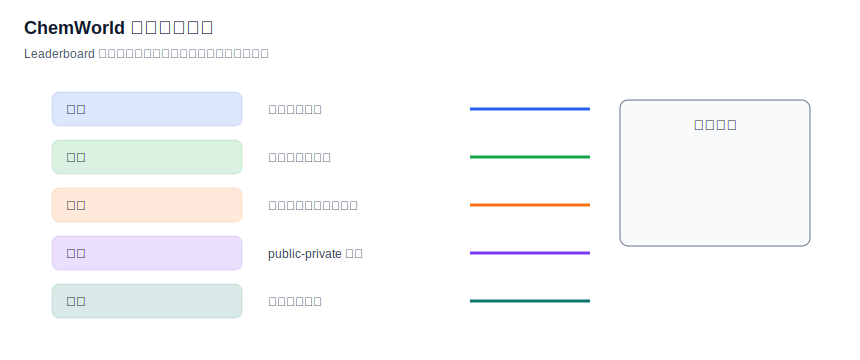

In [2]:
tu.display_tutorial_header(
    day=9,
    title='贝叶斯优化与安全 BO',
    subtitle='用 surrogate 和 acquisition function 在有限预算下选择下一轮实验。',
    focus=[
        'GP BO',
        'safe BO',
        'sample efficiency',
        'risk-aware acquisition',
    ],
    deliverables=[
        '一张收敛曲线',
        '一张安全对比表',
        '一段 exploration/exploitation 解释',
    ],
    project_link='BO 是 leaderboard 的强基线，也是判断 LLM 策略是否真正有增益的参照。',
)
tu.display_course_map(9)
display(tu.leaderboard_blueprint_svg())


In [3]:
tu.display_api_card()

## 第 9 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一张收敛曲线
- 一张安全对比表
- 一段探索与利用的解释


In [5]:
from chemworld.data.logging import load_jsonl
from chemworld.eval.metrics import evaluate_records
from chemworld.eval.runner import make_agent, run_agent

agents = ["lhs", "gp_bo", "safe_gp_bo"]
run_rows = []
curves = []
for agent_name in agents:
    path = OUTPUT_DIR / f"{agent_name}_seed0.jsonl"
    run_agent(
        env_id="ChemWorld",
        agent=make_agent(agent_name),
        world_split="public-test",
        budget=66,
        objective="balanced",
        seed=0,
        output_path=path,
    )
    records = load_jsonl(path)
    result = evaluate_records(records).to_dict()
    result["agent"] = agent_name
    run_rows.append(result)
    best = 0.0
    for record in records:
        score = record["leaderboard_score"] or 0.0
        best = max(best, score)
        curves.append(
            {
                "agent": agent_name,
                "step": record["step"],
                "best_score": best,
                "risk": record["observation"]["safety_risk"],
            }
        )
summary_df = pd.DataFrame(run_rows)
curve_df = pd.DataFrame(curves)
display(
    summary_df[
        [
            "agent",
            "steps",
            "final_best_score",
            "safety_violations",
            "mean_safety_risk",
            "total_score",
        ]
    ]
)

,agent,steps,final_best_score,safety_violations,mean_safety_risk,total_score
0,lhs,6,0.0000,0,0.2368,0.0000
1,gp_bo,6,0.0095,0,0.1306,0.0056
2,safe_gp_bo,6,0.0095,0,0.1306,0.0056


C:\Users\Admin\AppData\Local\Temp\ipykernel_30844\4098194401.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")


agent,step,gp_bo,lhs,safe_gp_bo
1,2,0.0000,0.0,0.0000
2,3,0.0000,0.0,0.0000
3,4,0.0000,0.0,0.0000
4,5,0.0000,0.0,0.0000
5,6,0.0095,0.0,0.0095


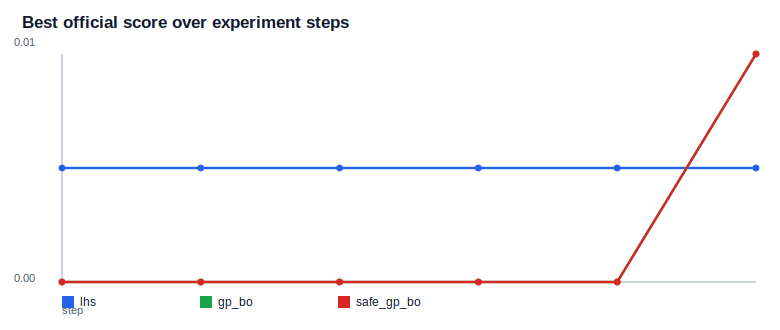

In [6]:
plot_df = (
    curve_df.pivot_table(index="step", columns="agent", values="best_score", aggfunc="max")
    .reset_index()
    .fillna(method="ffill")
    .fillna(0.0)
)
display(plot_df.tail())
display(
    tu.line_svg(plot_df, x="step", ys=agents, title="Best official score over experiment steps")
)

,agent,mean_step_risk,total_score,safety_violations
0,gp_bo,0.1306,0.0056,0
1,lhs,0.2368,0.0000,0
2,safe_gp_bo,0.1306,0.0056,0


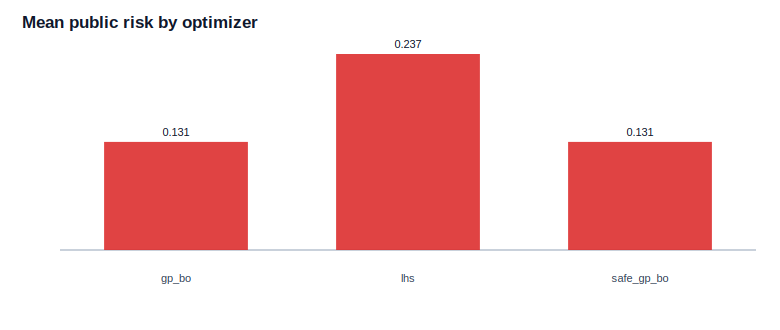

In [7]:
risk_df = (
    curve_df.groupby("agent", as_index=False)["risk"]
    .mean()
    .rename(columns={"risk": "mean_step_risk"})
)
risk_df = risk_df.merge(summary_df[["agent", "total_score", "safety_violations"]], on="agent")
display(risk_df)
display(
    tu.bar_svg(
        risk_df["agent"].tolist(),
        risk_df["mean_step_risk"].astype(float).tolist(),
        title="Mean public risk by optimizer",
        color="#dc2626",
    )
)

In [8]:
interpretation = {
    "bo_role": (
        "BO builds a local surrogate from finished recipes and uses uncertainty "
        "to choose the next recipe."
    ),
    "safe_bo_role": "Safe BO penalizes candidates whose predicted risk is too high.",
    "why_not_rl_yet": (
        "The current task is low-dimensional recipe optimization. RL becomes more useful "
        "for longer multi-step control tasks such as heating profiles or feed policies."
    ),
}
tu.show_json_panel("Optimizer interpretation", interpretation)

## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [9]:
tu.display_reflection_box(
    [
        'BO 相比 random 的优势来自哪里？',
        'safe BO 牺牲了什么，换来了什么？',
    ]
)
